In [17]:
# ============================================================
# 1. Python standard library
# ============================================================
import gc
import os
import re
import shutil
import tempfile
from datetime import datetime, timedelta
from pathlib import Path
from urllib.parse import urlparse


# ============================================================
# 2. STAC search and GCS download
# ============================================================
import gcsfs
from pystac_client import Client

# ============================================================
# 3. Boundary and raster processing
# ============================================================
import fiona
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.mask import mask
from rasterio.warp import reproject, transform_geom


# ============================================================
# 4. Image display
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from rasterio.plot import show

In [2]:
#the link to the stac in production
API_ROOT = "https://data.apps.fao.org/geospatial/search/stac"
#using client functions to see all collections available in the STAC
client = Client.open(API_ROOT)

In [7]:
#input filters for data selection
# === EDIT THESE ===
# You can put: []  or ""  or None  to search without a collection filter.
# Or provide one or many collection ids, e.g. ["L1-UTM-NPP-D"] or "L1-UTM-NPP-D"
COLLECTIONS = "MVHI-D"   # or [] or None
# Bounding box in WGS84 [minx, miny, maxx, maxy]; set to None to ignore
BBOX =[60, 29, 75, 39]   # or None
# Time range; set to None to ignore (STAC interval string "start/end")
#create the time as 15 days ago:
now = datetime.now()
days_ago = 25
#fifteen_days_ago = now - timedelta(days=days_ago)
endtime_str = (datetime.now() - timedelta(days=days_ago)).strftime("%Y-%m-%d")
#print(starttime_str)
DATETIME = "1992-01-01/"+endtime_str  # or None
# Optional: LIKE pattern for item id (SQL wildcards: % = any string, _ = single char)
# Example: "%60W.2024-12-D3%"  |  set to None to skip LIKE filtering
ITEM_ID_LIKE = "%.LC-C"
# Optional extra STAC 'query' filter
QUERY = {
    # "eo:cloud_cover": {"lt": 20}
}
# Optional cap on results
LIMIT = 100
print("STAC_API:", API_ROOT)
print("COLLECTIONS:", COLLECTIONS)
print("BBOX:", BBOX)
print("DATETIME:", DATETIME)
print("ITEM_ID_LIKE:", ITEM_ID_LIKE)

STAC_API: https://data.apps.fao.org/geospatial/search/stac
COLLECTIONS: MVHI-D
BBOX: [60, 29, 75, 39]
DATETIME: 1992-01-01/2026-08-01
ITEM_ID_LIKE: %.LC-C


In [8]:
#functions to select items from collection
def _normalize_collections(val):
    if val is None:
        return None
    if isinstance(val, str):
        val = val.strip()
        return [val] if val else None
    if isinstance(val, (list, tuple)):
        vals = [v for v in (x.strip() for x in val) if v]
        return vals or None
    return None

search_kwargs = dict(
    collections=_normalize_collections(COLLECTIONS),
    bbox=BBOX or None,
    datetime=DATETIME or None,
    query=QUERY or None,
    limit=LIMIT,
)

#get and show the list of the selected items of the recent 15 day.
# Add LIKE filter only if user provided ITEM_ID_LIKE
if ITEM_ID_LIKE:
    search_kwargs.update({
        "filter_lang": "cql2-json",
        "filter": {
            "op": "like",
            "args": [
                {"property": "id"},
                ITEM_ID_LIKE
            ]
        }
    })

search = client.search(**search_kwargs)
items = list(search.get_items())
for item in items:
    print(item.id)
#print(len(items))

ASIS.MVHI-D.2026-08-D1.GS2.LC-C
ASIS.MVHI-D.2026-08-D1.GS1.LC-C
ASIS.MVHI-D.2026-07-D3.GS2.LC-C
ASIS.MVHI-D.2026-07-D3.GS1.LC-C
ASIS.MVHI-D.2026-07-D2.GS2.LC-C
ASIS.MVHI-D.2026-07-D2.GS1.LC-C
ASIS.MVHI-D.2026-07-D1.GS2.LC-C
ASIS.MVHI-D.2026-07-D1.GS1.LC-C
ASIS.MVHI-D.2026-06-D3.GS2.LC-C
ASIS.MVHI-D.2026-06-D3.GS1.LC-C
ASIS.MVHI-D.2026-06-D2.GS2.LC-C
ASIS.MVHI-D.2026-06-D2.GS1.LC-C
ASIS.MVHI-D.2026-06-D1.GS2.LC-C
ASIS.MVHI-D.2026-06-D1.GS1.LC-C
ASIS.MVHI-D.2026-05-D3.GS2.LC-C
ASIS.MVHI-D.2026-05-D3.GS1.LC-C
ASIS.MVHI-D.2026-05-D2.GS2.LC-C
ASIS.MVHI-D.2026-05-D2.GS1.LC-C
ASIS.MVHI-D.2026-05-D1.GS2.LC-C
ASIS.MVHI-D.2026-05-D1.GS1.LC-C
ASIS.MVHI-D.2026-04-D3.GS2.LC-C
ASIS.MVHI-D.2026-04-D3.GS1.LC-C
ASIS.MVHI-D.2026-04-D2.GS2.LC-C
ASIS.MVHI-D.2026-04-D2.GS1.LC-C
ASIS.MVHI-D.2026-04-D1.GS2.LC-C
ASIS.MVHI-D.2026-04-D1.GS1.LC-C
ASIS.MVHI-D.2026-03-D3.GS2.LC-C
ASIS.MVHI-D.2026-03-D3.GS1.LC-C
ASIS.MVHI-D.2026-03-D2.GS2.LC-C
ASIS.MVHI-D.2026-03-D2.GS1.LC-C
ASIS.MVHI-D.2026-03-D1.GS2.LC-C
ASIS.MVH

In [12]:
# VM path
BASE_DIR = Path("/home/pengyu_hao_fao_org/RSP_test/AverageASIS-test")

# tmp path
TEMP_ROOT = BASE_DIR / "tmp"

# final output
OUTPUT_DIR = BASE_DIR / "output"

TEMP_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Temporary directory:", TEMP_ROOT)
print("Output directory:", OUTPUT_DIR)

Temporary directory: /home/pengyu_hao_fao_org/RSP_test/AverageASIS-test/tmp
Output directory: /home/pengyu_hao_fao_org/RSP_test/AverageASIS-test/output


In [14]:
# ============================================================
# GET AFGHANISTAN BOUNDARY
# ============================================================

shp_file = (
    "/home/pengyu_hao_fao_org/"
    "Boundary/Global/shp/Global.shp"
)

attribute_name = "ISO3CD"
attribute_value = "AFG"

geom = None
boundary_crs = None

with fiona.open(shp_file) as shp:

    boundary_crs = (
        shp.crs_wkt
        if shp.crs_wkt
        else shp.crs
    )

    for feature in shp:

        if (
            feature["properties"][attribute_name]
            == attribute_value
        ):

            geom = feature["geometry"]
            break


if geom is None:
    raise ValueError(
        f"Country {attribute_value} "
        f"not found in {shp_file}"
    )

if not boundary_crs:
    raise ValueError(
        f"Boundary CRS is missing: {shp_file}"
    )


print(
    "Country boundary found:",
    attribute_value
)

print(
    "Boundary CRS:",
    boundary_crs
)

Country boundary found: AFG
Boundary CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [16]:
# ============================================================
# MVHI-D LC-C MULTIYEAR MEAN
#
# Required variables from previous cells:
#   items
#   geom
#   boundary_crs
# ============================================================
# ============================================================
# 1. SETTINGS
# ============================================================

BASE_DIR = Path(
    "/home/pengyu_hao_fao_org/RSP_test/AverageASIS-test"
)

TEMP_ROOT = BASE_DIR / "tmp"
OUTPUT_DIR = BASE_DIR / "output"

# None = process all available phases
# Test example: ["06-D1"]
PHASES_TO_RUN = None

# GS1 and GS2 are calculated separately
SEASONS_TO_RUN = ["GS1", "GS2"]

# False = skip existing output
OVERWRITE = False

# Valid MVHI-D range
VALID_MIN = 0.0
VALID_MAX = 1.0

# Output NoData
OUTPUT_NODATA = 255.0

TEMP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
print("Temporary directory:", TEMP_ROOT)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# 2. GROUP LC-C ITEMS
# ============================================================
item_pattern = re.compile(
    r"^ASIS\.MVHI-D\."
    r"(?P<year>\d{4})-"
    r"(?P<phase>\d{2}-D[123])\."
    r"(?P<season>GS[12])\."
    r"LC-C$"
)
# groups[(phase, season)] = [(year, item), ...]
groups = {}
for item in items:
    match_result = item_pattern.match(
        item.id
    )
    # This also excludes LC-G items
    if match_result is None:
        continue
    year = int(
        match_result.group("year")
    )
    phase = match_result.group("phase")
    season = match_result.group("season")
    groups.setdefault(
        (phase, season),
        []
    ).append(
        (year, item)
    )
# Sort every group by year
for key in groups:
    groups[key].sort(
        key=lambda record: record[0]
    )
if not groups:
    raise RuntimeError(
        "No MVHI-D LC-C items were found "
        "in the existing items list."
    )

def phase_sort_key(phase):
    month, dekad = phase.split("-")
    return (
        int(month),
        int(dekad.replace("D", ""))
    )
available_phases = sorted(
    {
        phase
        for phase, season in groups
    },
    key=phase_sort_key
)
if PHASES_TO_RUN is None:

    phases = available_phases
else:
    phases = PHASES_TO_RUN
print("Available phases:", available_phases)
print("Phases to process:", phases)

# ============================================================
# 3. GCS CONNECTION
# ============================================================
# Reads the FAO source files and downloads them to TEMP_ROOT.
# Nothing is uploaded to a bucket.
gcs = gcsfs.GCSFileSystem(
    token="google_default"
)
def get_gcs_path(item):

    if "data" not in item.assets:
        raise KeyError(
            f"{item.id}: asset 'data' not found"
        )
    asset = item.assets["data"]
    alternate = asset.extra_fields.get(
        "alternate",
        {}
    )
    gs_asset = alternate.get("gs")
    if isinstance(gs_asset, dict):
        gs_href = gs_asset.get("href")
    else:
        gs_href = gs_asset
    if not gs_href:
        raise ValueError(
            f"{item.id}: GCS address not found"
        )
    return gs_href.removeprefix("gs://")

# ============================================================
# 4. DOWNLOAD, CLIP, CALCULATE AND OUTPUT
# ============================================================
def calculate_mean(
    phase,
    season,
    phase_items,
    phase_temp_dir
):
    years = [
        year
        for year, item in phase_items
    ]
    output_file = OUTPUT_DIR / (
        f"ASIS_MVHI-D_AFG_mean_"
        f"{phase}_{season}_LC-C_"
        f"{years[0]}-{years[-1]}.tif"
    )
    if output_file.exists() and not OVERWRITE:
        print(
            "Already exists, skipped:",
            output_file.name
        )

        return "skipped"

    pixel_sum = None
    pixel_count = None
    reference_shape = None
    output_transform = None
    output_profile = None
    output_crs = None

    for item_number, (year, item) in enumerate(
        phase_items,
        start=1
    ):
        local_file = (
            phase_temp_dir /
            f"{item.id}.tif"
        )
        print(
            f"  {season} "
            f"[{item_number:02d}/{len(phase_items):02d}] "
            f"{item.id}",
            flush=True
        )
        try:
            # ------------------------------------------------
            # Download annual raster to VM
            # ------------------------------------------------
            remote_path = get_gcs_path(
                item
            )
            gcs.get(
                remote_path,
                str(local_file)
            )
            # ------------------------------------------------
            # Clip to Afghanistan
            # ------------------------------------------------
            with rasterio.open(local_file) as src:
                if src.crs is None:
                    raise ValueError(
                        f"{item.id}: raster CRS is missing"
                    )
                # Transform local Global.shp geometry
                # to the raster CRS
                raster_geom = transform_geom(
                    boundary_crs,
                    src.crs,
                    geom
                )
                clipped, transform = mask(
                    src,
                    [raster_geom],
                    indexes=1,
                    crop=True,
                    filled=False,
                    all_touched=False
                )
                data = (
                    clipped
                    .astype("float32")
                    .filled(np.nan)
                )
                profile = src.profile.copy()
                crs = src.crs
            # ------------------------------------------------
            # Valid MVHI-D pixels
            # ------------------------------------------------
            valid = (
                np.isfinite(data)
                & (data >= VALID_MIN)
                & (data <= VALID_MAX)
            )
            # ------------------------------------------------
            # Initialize arrays using first annual raster
            # ------------------------------------------------
            if pixel_sum is None:
                reference_shape = data.shape
                output_transform = transform
                output_profile = profile
                output_crs = crs
                pixel_sum = np.zeros(
                    reference_shape,
                    dtype="float64"
                )
                pixel_count = np.zeros(
                    reference_shape,
                    dtype="uint16"
                )
            else:
                same_grid = (
                    data.shape == reference_shape
                    and transform.almost_equals(
                        output_transform
                    )
                    and crs == output_crs
                )
                if not same_grid:
                    raise ValueError(
                        f"{item.id}: raster grid differs "
                        "from other years"
                    )
            # ------------------------------------------------
            # Accumulate valid pixels
            # ------------------------------------------------
            pixel_sum[valid] += data[valid]
            pixel_count[valid] += 1
        finally:
            # Delete annual source raster immediately
            if local_file.exists():
                local_file.unlink()
            gc.collect()
    if pixel_sum is None:
        raise RuntimeError(
            f"{phase} {season}: "
            "no annual raster was processed"
        )
    # ========================================================
    # Calculate pixel-wise multiyear mean
    # ========================================================
    mean_array = np.full(
        reference_shape,
        OUTPUT_NODATA,
        dtype="float32"
    )
    np.divide(
        pixel_sum,
        pixel_count,
        out=mean_array,
        where=pixel_count > 0
    )
    # ========================================================
    # Prepare output GeoTIFF
    # ========================================================
    output_profile.update(
        driver="GTiff",
        height=mean_array.shape[0],
        width=mean_array.shape[1],
        transform=output_transform,
        crs=output_crs,
        count=1,
        dtype="float32",
        nodata=OUTPUT_NODATA,
        compress="DEFLATE",
        predictor=3,
        tiled=True,
        BIGTIFF="IF_SAFER"
    )
    temporary_output = output_file.with_suffix(
        ".partial.tif"
    )
    try:
        with rasterio.open(
            temporary_output,
            "w",
            **output_profile
        ) as dst:
            dst.write(
                mean_array,
                1
            )
            dst.set_band_description(
                1,
                "MVHI-D multiyear pixel mean"
            )
            dst.update_tags(
                country="AFG",
                collection="MVHI-D",
                phase=phase,
                growing_season=season,
                land_cover="LC-C",
                valid_range="0,1",
                years=",".join(
                    map(str, years)
                ),
                number_of_years=str(
                    len(years)
                )
            )
        # Rename only after successful writing
        os.replace(
            temporary_output,
            output_file
        )
    finally:
        if temporary_output.exists():
            temporary_output.unlink()
    print("  Saved:", output_file)
    return "written"

# ============================================================
# 5. PROCESS ALL PHASES
# ============================================================
completed = []
skipped = []
failures = []

for phase_number, phase in enumerate(
    phases,
    start=1
):
    print()
    print(
        f"========== "
        f"{phase_number:02d}/{len(phases):02d} "
        f"{phase} "
        f"=========="
    )
    # Separate temporary directory for every phase
    phase_temp_dir = Path(
        tempfile.mkdtemp(
            prefix=f"{phase}_",
            dir=TEMP_ROOT
        )
    )
    try:
        for season in SEASONS_TO_RUN:
            phase_items = groups.get(
                (phase, season),
                []
            )
            if not phase_items:
                print(
                    f"  {season}: no items, skipped"
                )
                continue
            print(
                f"  {season}: "
                f"{len(phase_items)} years, "
                f"{phase_items[0][0]}-"
                f"{phase_items[-1][0]}"
            )
            try:
                status = calculate_mean(
                    phase=phase,
                    season=season,
                    phase_items=phase_items,
                    phase_temp_dir=phase_temp_dir
                )
                if status == "written":
                    completed.append(
                        (phase, season)
                    )
                else:
                    skipped.append(
                        (phase, season)
                    )
            except Exception as error:
                failures.append(
                    (
                        phase,
                        season,
                        str(error)
                    )
                )
                print(
                    f"  FAILED: {phase} {season}",
                    error
                )
    finally:
        # Delete everything downloaded for this phase
        shutil.rmtree(
            phase_temp_dir,
            ignore_errors=True
        )
        gc.collect()
        print(
            f"  Temporary data deleted: {phase}"
        )

# ============================================================
# 6. SUMMARY
# ============================================================
print()
print("========== FINISHED ==========")
print(
    "New outputs:",
    len(completed)
)

print(
    "Existing outputs skipped:",
    len(skipped)
)
print(
    "Failures:",
    len(failures)
)
print(
    "Output directory:",
    OUTPUT_DIR
)
if failures:
    print("\nFailure details:")
    for phase, season, error in failures:
        print(
            f"- {phase} {season}: {error}"
        )

Temporary directory: /home/pengyu_hao_fao_org/RSP_test/AverageASIS-test/tmp
Output directory: /home/pengyu_hao_fao_org/RSP_test/AverageASIS-test/output
Available phases: ['01-D1', '01-D2', '01-D3', '02-D1', '02-D2', '02-D3', '03-D1', '03-D2', '03-D3', '04-D1', '04-D2', '04-D3', '05-D1', '05-D2', '05-D3', '06-D1', '06-D2', '06-D3', '07-D1', '07-D2', '07-D3', '08-D1', '08-D2', '08-D3', '09-D1', '09-D2', '09-D3', '10-D1', '10-D2', '10-D3', '11-D1', '11-D2', '11-D3', '12-D1', '12-D2', '12-D3']
Phases to process: ['01-D1', '01-D2', '01-D3', '02-D1', '02-D2', '02-D3', '03-D1', '03-D2', '03-D3', '04-D1', '04-D2', '04-D3', '05-D1', '05-D2', '05-D3', '06-D1', '06-D2', '06-D3', '07-D1', '07-D2', '07-D3', '08-D1', '08-D2', '08-D3', '09-D1', '09-D2', '09-D3', '10-D1', '10-D2', '10-D3', '11-D1', '11-D2', '11-D3', '12-D1', '12-D2', '12-D3']

========== 01/36 01-D1 ==========
  GS1: 35 years, 1992-2026
  GS1 [01/35] ASIS.MVHI-D.1992-01-D1.GS1.LC-C
  GS1 [02/35] ASIS.MVHI-D.1993-01-D1.GS1.LC-C
  GS1 [

Latest GS1 in items: ASIS.MVHI-D.2026-08-D1.GS1.LC-C
Time phase: 08-D1
Mean file: /home/pengyu_hao_fao_org/RSP_test/AverageASIS-test/output/ASIS_MVHI-D_AFG_mean_08-D1_GS1_LC-C_1992-2026.tif
Downloading: ASIS.MVHI-D.2026-08-D1.GS1.LC-C


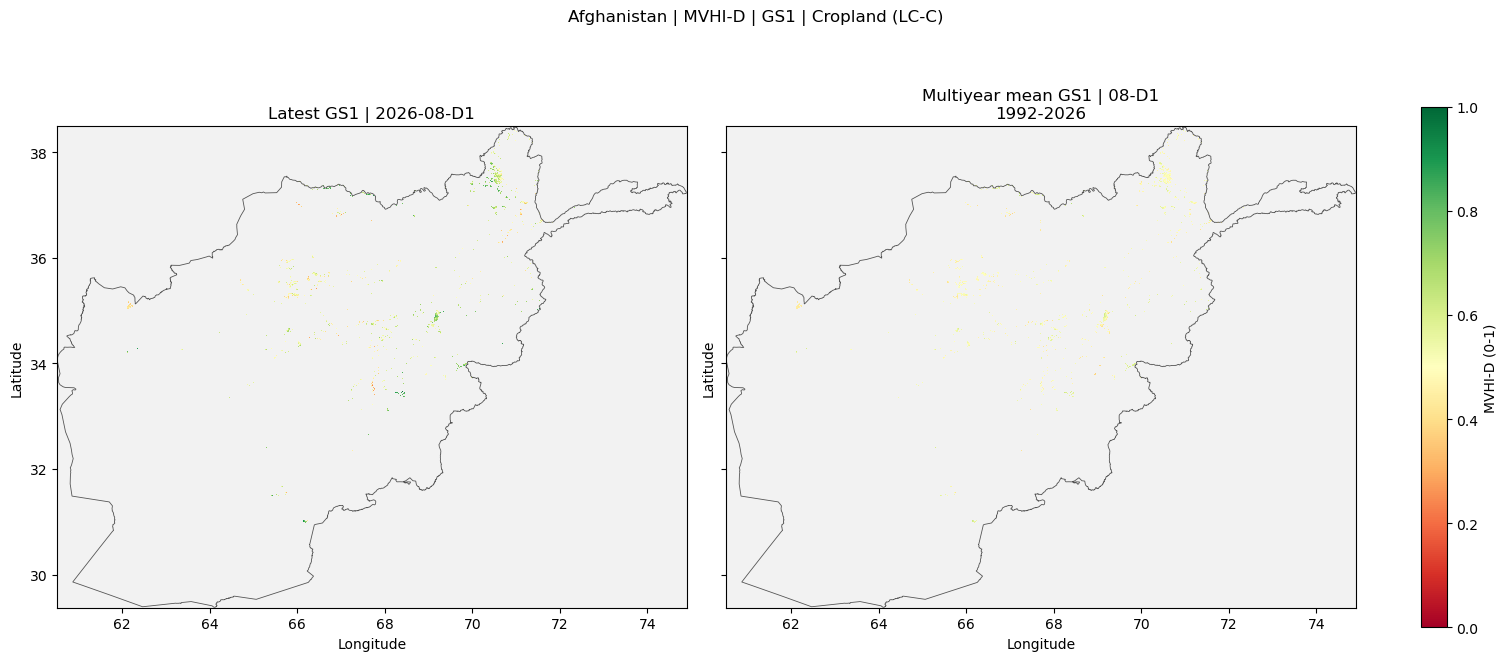

Grey: NoData / outside Afghanistan / values outside 0-1.
Temporary source deleted; mean GeoTIFF unchanged.


In [19]:
# ============================================================
# 2. FIND LATEST GS1 / LC-C ITEM
# ============================================================
MEAN_FILE_OVERRIDE = None
def select_latest_gs1(stac_items):
    pattern = re.compile(
        r"^ASIS\.MVHI-D\."
        r"(\d{4})-(0[1-9]|1[0-2])-D([123])"
        r"\.GS1\.LC-C$"
    )
    candidates = []
    for item in stac_items:
        match = pattern.fullmatch(item.id)
        if match:
            # sort all items
            time_key = tuple(map(int, match.groups()))
            candidates.append((time_key, item))
    if not candidates:
        raise ValueError(
            "No MVHI-D GS1 LC-C items found in items."
        )
    (year, month, dekad), item = max(
        candidates,
        key=lambda row: row[0]
    )
    return item, year, f"{month:02d}-D{dekad}"
latest_item, latest_year, latest_phase = select_latest_gs1(items)
print("Latest GS1 in items:", latest_item.id)
print("Time phase:", latest_phase)

# ============================================================
# 3. FIND MATCHING MEAN FILE
# ============================================================

prefix = (
    f"ASIS_MVHI-D_AFG_mean_"
    f"{latest_phase}_GS1_LC-C_"
)

mean_pattern = re.compile(
    re.escape(prefix) + r"(\d{4})-(\d{4})\.tif"
)

if MEAN_FILE_OVERRIDE is not None:
    mean_files = [Path(MEAN_FILE_OVERRIDE)]
    if not mean_pattern.fullmatch(mean_files[0].name):
        raise ValueError(
            "target filename not match with phase / GS1 / LC-C"
        )
else:
    mean_files = sorted(
        OUTPUT_DIR.glob(prefix + "*.tif")
    )

# to skip unfinished file
mean_files = [
    path for path in mean_files
    if path.is_file()
    and mean_pattern.fullmatch(path.name)
]

if not mean_files:
    raise FileNotFoundError(
        f"did not find average data for GS1 average {latest_phase}\n"
        f"please calculate the average of this time phase：{OUTPUT_DIR}"
    )

if len(mean_files) > 1:
    raise ValueError(
        "find multiple average file，please set MEAN_FILE_OVERRIDE：\n"
        + "\n".join(str(path) for path in mean_files)
    )

mean_file = mean_files[0]
first_year, last_year = (
    mean_pattern.fullmatch(mean_file.name).groups()
)

print("Mean file:", mean_file)


# ============================================================
# 4. READ AND CLIP TO AFGHANISTAN
# ============================================================

def read_afg_image(path):
    with rasterio.open(path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is missing: {path}")
        raster_geom = transform_geom(
            boundary_crs,
            src.crs,
            geom
        )
        clipped, transform = mask(
            src,
            [raster_geom],
            indexes=1,
            crop=True,
            filled=False,
            all_touched=False
        )
        data = clipped.astype("float32").filled(np.nan)
        crs = src.crs
    # keep original NoData (to mask 251–255 as data flag)
    data[
        ~np.isfinite(data)
        | (data < 0)
        | (data > 1)
    ] = np.nan
    return data, transform, crs
mean_data, mean_transform, mean_crs = read_afg_image(
    mean_file
)
TEMP_ROOT.mkdir(parents=True, exist_ok=True)

# only download the latest data
with tempfile.TemporaryDirectory(
    prefix="display_GS1_",
    dir=TEMP_ROOT
) as tmp_dir:
    local_file = Path(tmp_dir) / f"{latest_item.id}.tif"
    print("Downloading:", latest_item.id, flush=True)
    gcs.get(
        get_gcs_path(latest_item),
        str(local_file)
    )
    latest_data, latest_transform, latest_crs = (
        read_afg_image(local_file)
    )

# ============================================================
# 5. ALIGN DISPLAY GRID IF NECESSARY
# ============================================================

same_grid = (
    latest_data.shape == mean_data.shape
    and latest_transform.almost_equals(mean_transform)
    and latest_crs == mean_crs
)
if not same_grid:
    aligned = np.full(
        mean_data.shape,
        np.nan,
        dtype="float32"
    )
    reproject(
        source=latest_data,
        destination=aligned,
        src_transform=latest_transform,
        src_crs=latest_crs,
        src_nodata=np.nan,
        dst_transform=mean_transform,
        dst_crs=mean_crs,
        dst_nodata=np.nan,
        resampling=Resampling.nearest
    )
    latest_data = aligned
    latest_transform = mean_transform
    latest_crs = mean_crs
    print("Latest image aligned to mean grid for display.")
plot_geom = transform_geom(
    boundary_crs,
    mean_crs,
    geom
)
inside_afg = geometry_mask(
    [plot_geom],
    out_shape=mean_data.shape,
    transform=mean_transform,
    invert=True,
    all_touched=False
)
latest_data[~inside_afg] = np.nan

# ============================================================
# 6. DISPLAY
# ============================================================

def draw_boundary(ax, geometry):
    if geometry["type"] == "Polygon":
        polygons = [geometry["coordinates"]]
    elif geometry["type"] == "MultiPolygon":
        polygons = geometry["coordinates"]
    elif geometry["type"] == "GeometryCollection":
        for part in geometry["geometries"]:
            draw_boundary(ax, part)
        return
    else:
        return
    for polygon in polygons:
        for ring in polygon:
            xy = np.asarray(ring)
            ax.plot(
                xy[:, 0],
                xy[:, 1],
                color="#555555",
                linewidth=0.6
            )
cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("#f2f2f2")
norm = Normalize(vmin=0, vmax=1)
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 7),
    sharex=True,
    sharey=True,
    constrained_layout=True
)
titles = [
    f"Latest GS1 | {latest_year}-{latest_phase}",
    (
        f"Multiyear mean GS1 | {latest_phase}\n"
        f"{first_year}-{last_year}"
    )
]
for ax, data, title in zip(
    axes,
    [latest_data, mean_data],
    titles
):
    show(
        np.ma.masked_invalid(data),
        transform=mean_transform,
        ax=ax,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    draw_boundary(ax, plot_geom)
    ax.set_title(title)
    ax.set_xlabel(
        "Longitude" if mean_crs.is_geographic else "X"
    )
    ax.set_ylabel(
        "Latitude" if mean_crs.is_geographic else "Y"
    )
    if mean_crs.is_geographic:
        centre_lat = sum(ax.get_ylim()) / 2
        ax.set_aspect(
            1 / np.cos(np.deg2rad(centre_lat))
        )
    if not np.isfinite(data).any():
        ax.text(
            0.5, 0.5,
            "No valid MVHI-D pixels (0-1)",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
fig.colorbar(
    axes[0].images[0],
    ax=axes,
    shrink=0.78,
    label="MVHI-D (0-1)",
    ticks=np.linspace(0, 1, 6)
)
fig.suptitle(
    "Afghanistan | MVHI-D | GS1 | Cropland (LC-C)"
)
plt.show()
print("Grey: NoData / outside Afghanistan / values outside 0-1.")
print("Temporary source deleted; mean GeoTIFF unchanged.")